In [2]:
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
log_prob_matrix_d = np.load('log_prob.npy')

In [4]:
log_prob_matrix_d.shape

(100, 5000)

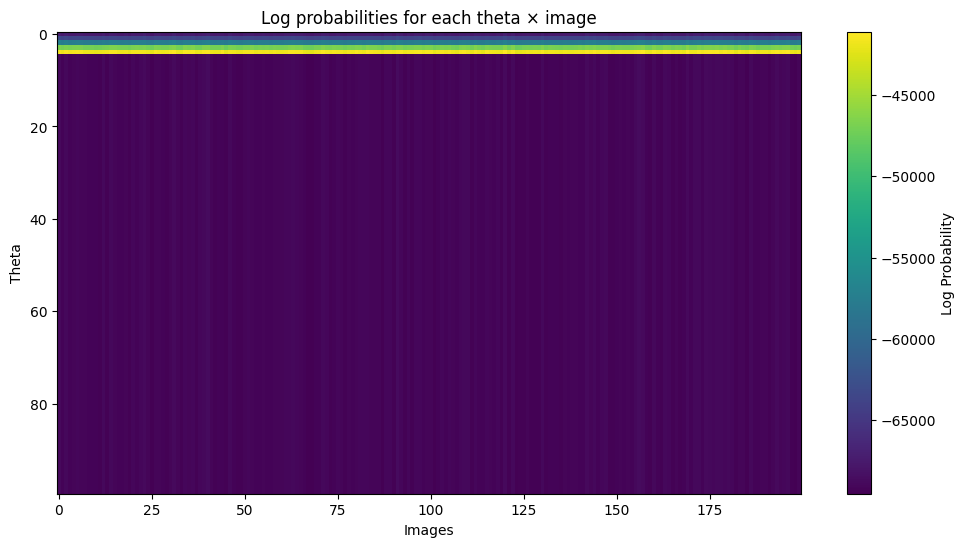

In [5]:
plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d[:200,:200], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [6]:
# GENERAL PARAMETERS
# number of models
nframes=100#121
# number of maps
nmaps=5000 #3255453

In [7]:
# Objective function
def F(X):
    s = P.T @ X  # shape (M,)
    return -np.sum(np.log(s))

# Gradient
def grad_F(X):
    s = P.T @ X  # shape (M,)

    return -P @ (1.0 / s)  # shape (N,)

# minimizer
class ProjectedGradientDescentSimplex:
    def __init__(self, func, grad, n_vars, max_iters=10000, tol=1e-9):
        """
        func: callable f(x) -> float
        grad: callable grad_f(x) -> np.ndarray
        n_vars: number of variables
        max_iters: maximum iterations
        tol: tolerance for convergence
        """
        self.func = func
        self.grad = grad
        self.n_vars = n_vars
        self.max_iters = max_iters
        self.tol = tol
        self.history = []  # store f(x) values

    def project_to_simplex(self, v):
        """ Project v onto the unit simplex {x | sum(x)=1, x>=0} """
        n = len(v)
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.nonzero(u * np.arange(1, n+1) > (cssv - 1))[0][-1]
        
        theta = (cssv[rho] - 1.0) / (rho + 1)
        return np.maximum(v - theta, 0.0)


    def minimize(self, x0=None):
        # Initialize
        if x0 is None:
            x = np.random.rand(self.n_vars)
        else:
            x = np.array(x0, dtype=np.float64)
        x = self.project_to_simplex(x)

        self.history = [self.func(x)]

        for i in range(self.max_iters):
            grad = self.grad(x)
            f_val = self.func(x)
            

            # Backtracking line search
            step = 1.0
            while True:
                x_new = self.project_to_simplex(x - step * grad)
                
                if self.func(x_new) <= f_val - 1e-4 * step * np.dot(grad, x - x_new):
                    break
                step *= 0.5
                if step < 1e-12:
                    break

            self.history.append(self.func(x_new))

            # Convergence check
            if np.linalg.norm(x_new - x) < self.tol:
                print(f"Converged in {i} iterations")
                return x_new

            x = x_new

        print("Reached maximum iterations")
        return x

    def plot_convergence(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.history, marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("f(x)")
        plt.title("Convergence of Projected Gradient Descent")
        plt.grid(True)
        plt.show()

In [8]:
# create probability array
P = np.array(log_prob_matrix_d, dtype=np.float64)
# get maximum value
m = np.max(P)
# get likelihood probability matrix Nmodels*Nimages
P = np.exp(P-m)
# convert Nan or weird values into zero
#P = np.nan_to_num(P, nan=0.0, posinf=0.0, neginf=0.0)
# Make initial random weight vector the size of the number of nframes-1
w_i = np.random.random(nframes-1)
# sort values and insert 0 and 1
w_t = np.append(np.insert(np.sort(w_i), 0, 0.0), 1.0)
# Prepare weight array
X0 = np.zeros(nframes, dtype=np.float64)
# Loop through frames & subtract value n from value n+1
for b in range(nframes):
    X0[b] = w_t[b+1] - w_t[b]

In [9]:
print("X0:", X0)
print("Sum:", np.sum(X0))
print("Min:", np.min(X0))


X0: [0.01029559 0.00132645 0.00931681 0.00110157 0.00442573 0.00184191
 0.0024813  0.03401094 0.00768026 0.03002615 0.01192572 0.00083577
 0.01366822 0.00311915 0.01429094 0.00058768 0.00366372 0.01820998
 0.0124218  0.01761097 0.00128944 0.01243652 0.00624546 0.00929469
 0.00865275 0.01895331 0.00928403 0.00225781 0.00284482 0.00266266
 0.06005628 0.01094345 0.00714235 0.00594812 0.00078943 0.00594673
 0.02534414 0.00027607 0.00541033 0.00790306 0.0019593  0.00126352
 0.00255412 0.01025857 0.00114553 0.00617442 0.00914862 0.03156275
 0.00087782 0.00377417 0.0130932  0.03110648 0.00776414 0.00047905
 0.05465798 0.01087726 0.0079619  0.00602911 0.00080942 0.00850281
 0.03287503 0.00314886 0.00292011 0.00391413 0.0176829  0.02406363
 0.00147525 0.00323697 0.01176736 0.0038009  0.00463771 0.0144547
 0.0203016  0.02738611 0.0042794  0.01226894 0.00064209 0.00236151
 0.01011036 0.01052926 0.00728864 0.00228485 0.00191974 0.00405867
 0.00327783 0.00089685 0.00365936 0.01600434 0.03737068 0.0

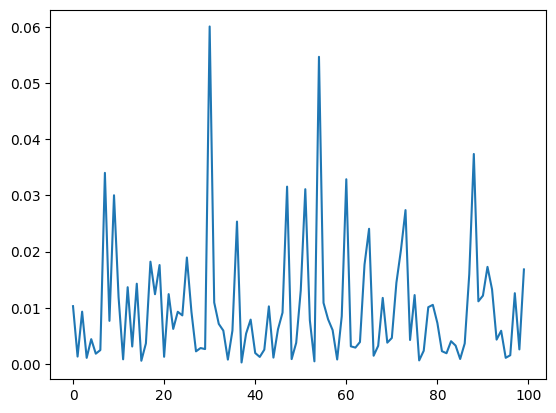

In [10]:
plt.plot(X0)

In [11]:
X0

array([0.01029559, 0.00132645, 0.00931681, 0.00110157, 0.00442573,
       0.00184191, 0.0024813 , 0.03401094, 0.00768026, 0.03002615,
       0.01192572, 0.00083577, 0.01366822, 0.00311915, 0.01429094,
       0.00058768, 0.00366372, 0.01820998, 0.0124218 , 0.01761097,
       0.00128944, 0.01243652, 0.00624546, 0.00929469, 0.00865275,
       0.01895331, 0.00928403, 0.00225781, 0.00284482, 0.00266266,
       0.06005628, 0.01094345, 0.00714235, 0.00594812, 0.00078943,
       0.00594673, 0.02534414, 0.00027607, 0.00541033, 0.00790306,
       0.0019593 , 0.00126352, 0.00255412, 0.01025857, 0.00114553,
       0.00617442, 0.00914862, 0.03156275, 0.00087782, 0.00377417,
       0.0130932 , 0.03110648, 0.00776414, 0.00047905, 0.05465798,
       0.01087726, 0.0079619 , 0.00602911, 0.00080942, 0.00850281,
       0.03287503, 0.00314886, 0.00292011, 0.00391413, 0.0176829 ,
       0.02406363, 0.00147525, 0.00323697, 0.01176736, 0.0038009 ,
       0.00463771, 0.0144547 , 0.0203016 , 0.02738611, 0.00427

In [12]:
# run minimization
pgd = ProjectedGradientDescentSimplex(func=F, grad=grad_F, n_vars=nframes)
x_opt = pgd.minimize(X0)

print("Optimal x:", x_opt)
print("Sum of x:", np.sum(x_opt))
print("Minimum f(x):", F(x_opt))




/tmp/ipykernel_173011/1738522426.py:4: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(s))
/tmp/ipykernel_173011/1738522426.py:10: RuntimeWarning: divide by zero encountered in divide
  return -P @ (1.0 / s)  # shape (N,)
/tmp/ipykernel_173011/1738522426.py:10: RuntimeWarning: overflow encountered in divide
  return -P @ (1.0 / s)  # shape (N,)
/tmp/ipykernel_173011/1738522426.py:10: RuntimeWarning: invalid value encountered in matmul
  return -P @ (1.0 / s)  # shape (N,)


IndexError: index -1 is out of bounds for axis 0 with size 0

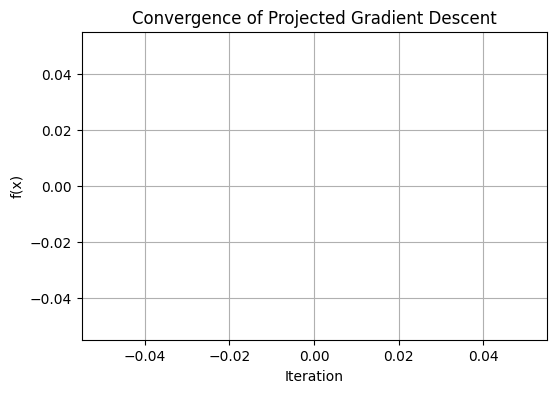

In [36]:
# Plot convergence
pgd.plot_convergence()

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(x_opt, bins=100, color='skyblue', edgecolor='black')
plt.show()

In [ ]:
x_opt.shape


In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d, aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("Images")
plt.ylabel("Theta / Conformations")
plt.title("Log-Likelihood Matrix")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(log_prob_matrix_d[:100,:100], aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel("Images")
plt.ylabel("Theta / Conformations")
plt.title("Log-Likelihood Matrix")
plt.show()

    
    
plt.figure(figsize=(12, 4))
plt.plot(x_opt, marker='o')
plt.xlabel("Theta / Conformations")
plt.ylabel("Normalized Weight")
plt.title("Weights per Theta")
plt.grid(True)
plt.show()
    
    
plt.figure(figsize=(8,4))
plt.hist(x_opt.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Normalized Weight")
plt.ylabel("Frequency")
plt.title("Histogram of Normalized Weights")
plt.show()
    
    
print("Weights stats:")
print("Mean:", x_opt.mean())
print("Std:", x_opt.std())
print("Min:", x_opt.min())
print("Max:", x_opt.max())

In [ ]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 0  # first image
log_probs_for_image = log_prob_matrix_d[:, image_idx]

# Convert log-prob to probability for nicer visualization
probs_for_image = np.exp(log_probs_for_image - np.max(log_probs_for_image))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()

In [ ]:
# log_prob_matrix_d is your likelihood matrix [num_theta, num_images]
# Example: log_prob_matrix_d.shape == (100, 5000)

# Pick an image to visualize
image_idx = 2200  # first image
log_probs_for_image = log_prob_matrix_d[:, image_idx]

# Convert log-prob to probability for nicer visualization
probs_for_image = np.exp(log_probs_for_image - np.max(log_probs_for_image))

# Normalize to sum to 1
probs_for_image /= probs_for_image.sum()

# Plot
plt.figure(figsize=(8, 4))
plt.plot(probs_for_image, marker='o')
plt.xlabel("Theta index")
plt.ylabel("Probability")
plt.title(f"Likelihood distribution over θ for image {image_idx}")
plt.grid(True)
plt.show()